In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../../Data/placement_or_not.csv")
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


# Finding Outlier

In [4]:
highest_allowed_marks = df['placement_exam_marks'].quantile(0.99) 
lowest_allowed_marks = df['placement_exam_marks'].quantile(0.01) 
highest_allowed_marks, lowest_allowed_marks

(np.float64(87.0), np.float64(4.0))

In [5]:
df[(df['placement_exam_marks'] > highest_allowed_marks) | (df['placement_exam_marks'] < lowest_allowed_marks)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
74,6.16,3.0,1
117,7.11,0.0,1
134,6.33,93.0,0
162,7.80,90.0,0
219,5.48,3.0,0
324,6.64,90.0,0
630,6.56,96.0,1
701,6.74,2.0,1
730,6.14,90.0,1


In [6]:
print(df.shape)
print(df[(df['placement_exam_marks'] <= highest_allowed_marks) & (df['placement_exam_marks'] >= lowest_allowed_marks)].shape)

(1000, 3)
(986, 3)


# way-1: Trim outlier

In [7]:
df_trim = df[(df['placement_exam_marks'] <= highest_allowed_marks) & (df['placement_exam_marks'] >= lowest_allowed_marks)]
df_trim

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


# way-2: Cap outlier

In [8]:
df_cap = df.copy()
df_cap['placement_exam_marks'] = np.where(
    df['placement_exam_marks'] > highest_allowed_marks,
    highest_allowed_marks,
    np.where(
        df['placement_exam_marks'] < lowest_allowed_marks,
        lowest_allowed_marks,
        df['placement_exam_marks']
    )
)

# Show Distribution

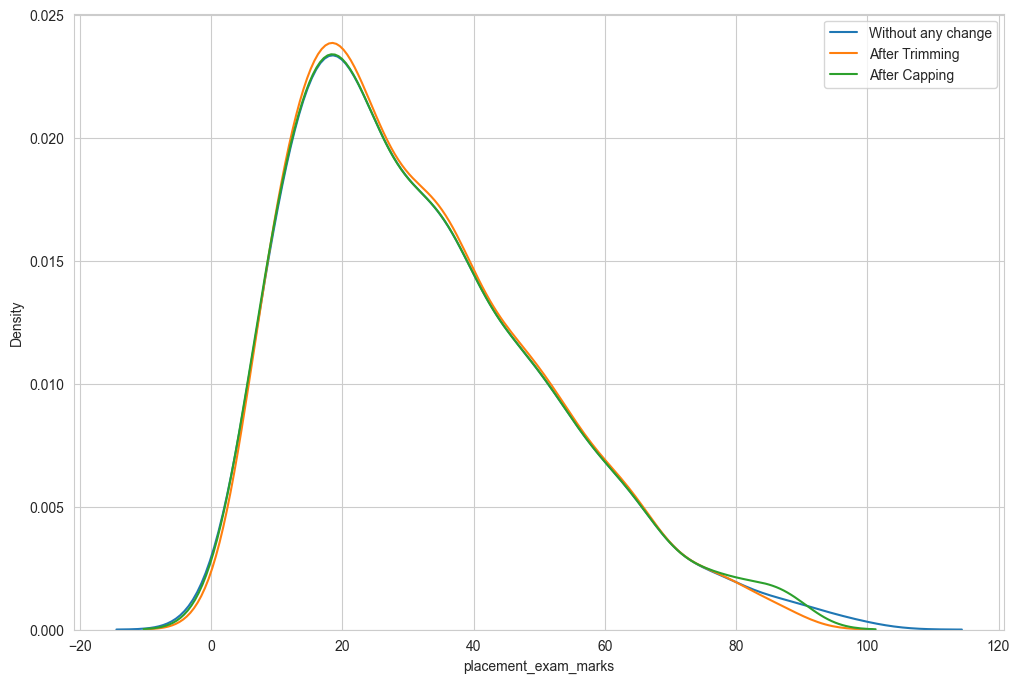

In [9]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=df,x='placement_exam_marks', label="Without any change")
sns.kdeplot(data=df_trim,x='placement_exam_marks', label="After Trimming")
sns.kdeplot(data=df_cap,x='placement_exam_marks', label="After Capping")
plt.legend()